# <u>**Calibração de Câmeras**</u>

**<u>Integrantes</u>**

- Gabriel Intackli Pinto - 11201921426

- Lucas Medeiros da Silva - 11202130277

- Samira Haddad - 11201812350

**Data de Realização dos Experimentos**:

01/07/2027

**Data de Publicação do Relatório**

06/07/2026

## <u>Introdução</u>

A calibração de câmeras é um processo fundamental na área de Visão Computacional. As câmeras atuam como a ponte entre o mundo tridimensional físico e o plano bidimensional digital. No entanto, o processo de captura de luz através de lentes reais introduz imperfeições na imagem, sendo as mais comuns a **distorção radial** (efeito barril ou almofada) e a **distorção tangencial** (desalinhamento da lente com o sensor).

Para que algoritmos de visão computacional possam medir distâncias, reconstruir cenários em 3D ou realizar rastreamento preciso, é necessário corrigir essas distorções e descobrir as propriedades geométricas exatas da câmera utilizada. Isso é feito através do cálculo dos seus parâmetros intrínsecos e extrínsecos.

Neste trabalho, realizamos a calibração computacional de duas lentes distintas — uma webcam e uma câmera pessoal (smartphone) — utilizando a biblioteca OpenCV em Python. O processo foi baseado na detecção de um padrão geométrico conhecido: um tabuleiro de xadrez impresso (checkerboard).

**Os principais objetivos deste relatório são:**
1. **Extrair e modelar matematicamente** os parâmetros da câmera, incluindo a matriz intrínseca (distância focal e centro óptico), os vetores de distorção da lente e as matrizes extrínsecas (rotação e translação) no espaço tridimensional.
2. **Comparar analiticamente** as características ópticas e os perfis de distorção entre a webcam (otimizada para vídeo a curtas distâncias) e a câmera do smartphone (projetada para fotografia de alta resolução).
3. **Aplicar a correção visual** em imagens do mundo real utilizando os parâmetros obtidos, validando a eficácia matemática dos métodos de desdobramento computacional (`undistort` e `remap`).

Ao longo das seções seguintes, apresentaremos os códigos desenvolvidos, os parâmetros numéricos extraídos, as comparações técnicas e a comprovação visual das correções de distorção.

## <u>Fundamentação Teórica</u>

A calibração de câmeras baseia-se em relacionar as coordenadas 3D de um ponto no espaço físico com as suas respectivas coordenadas 2D no plano da imagem digital. Para que essa transformação seja calculada computacionalmente, utilizamos o **Modelo de Câmera Pinhole** (câmera escura) aliado aos modelos matemáticos de distorção de lentes.

#### 1. O Modelo Pinhole e a Geometria da Câmera
O modelo pinhole descreve a projeção matemática da luz em uma câmera ideal, onde a abertura (lente) é considerada um único ponto. A relação entre um ponto 3D no mundo real $P = (X, Y, Z)$ e a sua projeção 2D na imagem $p = (u, v)$ é dada pela seguinte equação matricial:

$$s \begin{bmatrix} u \\ v \\ 1 \end{bmatrix} = \begin{bmatrix} f_x & \gamma & c_x \\ 0 & f_y & c_y \\ 0 & 0 & 1 \end{bmatrix} \begin{bmatrix} r_{11} & r_{12} & r_{13} & t_x \\ r_{21} & r_{22} & r_{23} & t_y \\ r_{31} & r_{32} & r_{33} & t_z \end{bmatrix} \begin{bmatrix} X \\ Y \\ Z \\ 1 \end{bmatrix}$$

Onde:
* $s$ é um fator de escala arbitrário.
* A primeira matriz ($3 \times 3$) representa os **Parâmetros Intrínsecos**.
* A segunda matriz ($3 \times 4$) representa os **Parâmetros Extrínsecos**.

#### 2. Parâmetros Intrínsecos (Matriz $K$)
Estes parâmetros são inerentes ao hardware da câmera, dependendo exclusivamente da forma como a lente e o sensor de imagem foram construídos. Permanecem constantes a menos que o foco da lente mude. A matriz intrínseca $K$ é composta por:
* $f_x$ e $f_y$: Distância focal medida em pixels ao longo dos eixos X e Y.
* $c_x$ e $c_y$: Coordenadas do ponto principal (centro óptico), geralmente próximo ao centro geométrico da imagem.
* $\gamma$: Fator de cisalhamento (*skew*), que modela a não-ortogonalidade entre os eixos x e y do sensor (comumente é $0$ em câmeras modernas).

#### 3. Parâmetros Extrínsecos ($R$ e $t$)
Eles descrevem a posição e a orientação da câmera no espaço tridimensional em relação a um referencial externo (neste projeto, o tabuleiro de xadrez). Variam a cada nova foto tirada em uma posição diferente.
* **Matriz de Rotação ($R$):** Uma matriz ortogonal $3 \times 3$ que alinha os eixos do mundo com os eixos da câmera.
* **Vetor de Translação ($t$):** Um vetor $3 \times 1$ que descreve o deslocamento físico da origem do mundo até o centro óptico da câmera.

#### 4. Distorção da Lente
Lentes reais não se comportam como o modelo pinhole perfeito, pois sofrem aberrações devido à sua curvatura e montagem. Os dois tipos principais de distorção são:

* **Distorção Radial:** Ocorre quando os raios de luz sofrem maior refração nas bordas da lente do que no centro óptico. Pode ser do tipo "barril" (linhas retas curvam-se para fora) ou "almofada" (linhas retas curvam-se para dentro). É corrigida pelo seguinte polinômio matemático, utilizando os coeficientes $k_1, k_2$ e $k_3$:
$$x_{corrigido} = x (1 + k_1 r^2 + k_2 r^4 + k_3 r^6)$$
$$y_{corrigido} = y (1 + k_1 r^2 + k_2 r^4 + k_3 r^6)$$

* **Distorção Tangencial:** Ocorre quando a lente da câmera não está perfeitamente paralela ao plano do sensor de imagem. É corrigida pelos coeficientes $p_1$ e $p_2$:
$$x_{corrigido} = x + [2 p_1 x y + p_2 (r^2 + 2x^2)]$$
$$y_{corrigido} = y + [p_1 (r^2 + 2y^2) + 2 p_2 x y]$$

#### 5. O Método de Calibração (Método de Zhang)
Para descobrir todos os parâmetros citados acima, o algoritmo utiliza o método proposto por Zhengyou Zhang (2000). Ele consiste em observar um padrão planar com geometria rigorosamente conhecida — como um tabuleiro de xadrez (*checkerboard*). Ao fixarmos que todas as coordenadas $Z$ do tabuleiro são $0$ no espaço mundial (pois ele é plano), o algoritmo reduz a complexidade da equação da câmera e utiliza a correlação entre os cantos detectados na imagem 2D e os pontos 3D ideais para resolver os parâmetros $K$, $dist$, $R$ e $t$ através de otimização matemática de mínimos quadrados.

## <u>Procedimentos Experimentais</u>



###Parte 2

(A) O procedimento de calibração de câmera com imagens fornecidas de exemplo: O programa
“L4_cal.py” realiza a calibração de cameras conforme o exemplo do item 2.b) acima. Execute este
programa dentro da pasta descompactada com as imagens fornecidas, e verifique o resultado

In [ ]:
import cv2
import numpy as np
import os
import glob

# Defining the dimensions of checkerboard
CHECKERBOARD = (6,9)
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001)

# Creating vector to store vectors of 3D points for each checkerboard image
objpoints = []
# Creating vector to store vectors of 2D points for each checkerboard image
imgpoints = []


# Defining the world coordinates for 3D points
objp = np.zeros((1, CHECKERBOARD[0] * CHECKERBOARD[1], 3), np.float32)
objp[0,:,:2] = np.mgrid[0:CHECKERBOARD[0], 0:CHECKERBOARD[1]].T.reshape(-1, 2)
prev_img_shape = None

# Extracting path of individual image stored in a given directory
images = glob.glob('*.jpg')
for fname in images:
    img = cv2.imread(fname)
    gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
    # Find the chess board corners
    # If desired number of corners are found in the image then ret = true
    ret, corners = cv2.findChessboardCorners(gray, CHECKERBOARD, cv2.CALIB_CB_ADAPTIVE_THRESH + cv2.CALIB_CB_FAST_CHECK + cv2.CALIB_CB_NORMALIZE_IMAGE)

    """
    If desired number of corner are detected,
    we refine the pixel coordinates and display
    them on the images of checker board
    """
    if ret == True:
        objpoints.append(objp)
        # refining pixel coordinates for given 2d points.
        corners2 = cv2.cornerSubPix(gray, corners, (11,11),(-1,-1), criteria)

        imgpoints.append(corners2)

        # Draw and display the corners
        img = cv2.drawChessboardCorners(img, CHECKERBOARD, corners2, ret)

    cv2.imshow('img',img)
    cv2.waitKey(0)

cv2.destroyAllWindows()

h,w = img.shape[:2]

"""
Performing camera calibration by
passing the value of known 3D points (objpoints)
and corresponding pixel coordinates of the
detected corners (imgpoints)
"""
ret, mtx, dist, rvecs, tvecs = cv2.calibrateCamera(objpoints, imgpoints, gray.shape[::-1], None, None)

print("Camera matrix : \n")
print(mtx)
print("dist : \n")
print(dist)
print("rvecs : \n")
print(rvecs)
print("tvecs : \n")
print(tvecs)


<u>Pergunta</u>: Liste todos os parametros obtidos, colocando-os nas formas de matrizes e vetores
(Matriz K, matriz R, vetor t, e dist ).
Explique o significado de K, R, t, e dist.

<u>Resposta</u>:

Significado dos Parâmetros

* **Matriz $K$ (Matriz da Câmera / Parâmetros Intrínsecos):** Representa as características internas da câmera. Ela mapeia pontos 3D no referencial da câmera para pontos 2D na imagem de pixel. Contém a distância focal (nos eixos x e y) e o centro óptico (ponto principal) da imagem.
* **Vetor $dist$ (Coeficientes de Distorção):** Modela a distorção da lente da câmera. Geralmente contém os coeficientes de distorção radial (que causam o efeito "olho de peixe" ou "barril") e distorção tangencial (quando a lente não está perfeitamente paralela ao sensor de imagem).
* **Matriz/Vetor $R$ (Parâmetros Extrínsecos - Rotação):** Representa a rotação da câmera em relação ao sistema de coordenadas do mundo (neste caso, o tabuleiro de xadrez) para cada imagem capturada. O OpenCV retorna isso como vetores de Rodrigues, que podem ser convertidos em matrizes de rotação 3x3.
* **Vetor $t$ (Parâmetros Extrínsecos - Translação):** Representa o deslocamento físico (translação) da câmera em relação à origem do sistema de coordenadas do mundo para cada imagem capturada.

---
Parâmetros Obtidos

#### 1. Matriz da Câmera ($K$)
$$\begin{bmatrix} 536.07345295 & 0 & 342.37047283 \\ 0 & 536.01636331 & 235.53687701 \\ 0 & 0 & 1 \end{bmatrix}$$

#### 2. Coeficientes de Distorção ($dist$)
$$\begin{bmatrix} -0.26509044 & -0.04674186 & 0.00183301 & -0.00031469 & 0.25231154 \end{bmatrix}$$

#### 3. Vetores de Rotação ($R$) e Translação ($t$)
Como os parâmetros extrínsecos dependem da posição da câmera em cada foto, temos um par de vetores para cada uma das 13 imagens processadas:

* **Imagem 1:** $R_1 = \begin{bmatrix} -0.08398729 \\ 0.34802798 \\ -1.54244125 \end{bmatrix}, t_1 = \begin{bmatrix} -2.96218417 \\ 0.57158932 \\ 16.83013775 \end{bmatrix}$
* **Imagem 2:** $R_2 = \begin{bmatrix} -0.27527313 \\ 0.10123349 \\ -1.56296568 \end{bmatrix}, t_2 = \begin{bmatrix} -3.99388098 \\ 2.27704343 \\ 12.68878108 \end{bmatrix}$
* **Imagem 3:** $R_3 = \begin{bmatrix} -0.22584613 \\ 1.0155115 \\ -2.79470623 \end{bmatrix}, t_3 = \begin{bmatrix} 2.53399419 \\ 4.31999128 \\ 13.71919122 \end{bmatrix}$
* **Imagem 4:** $R_4 = \begin{bmatrix} 0.05280128 \\ -0.60171832 \\ -0.18453815 \end{bmatrix}, t_4 = \begin{bmatrix} -2.16838794 \\ -3.50011196 \\ 10.73694991 \end{bmatrix}$
* **Imagem 5:** $R_5 = \begin{bmatrix} -0.10141629 \\ 0.32034812 \\ 0.3147293 \end{bmatrix}, t_5 = \begin{bmatrix} -3.72585434 \\ -4.3108485 \\ 17.20439703 \end{bmatrix}$
* **Imagem 6:** $R_6 = \begin{bmatrix} -0.34698232 \\ -0.06738512 \\ -1.20088998 \end{bmatrix}, t_6 = \begin{bmatrix} -3.427436 \\ 0.4873819 \\ 11.56153507 \end{bmatrix}$
* **Imagem 7:** $R_7 = \begin{bmatrix} 0.06525918 \\ 0.44701842 \\ 0.10800013 \end{bmatrix}, t_7 = \begin{bmatrix} 2.20741839 \\ -3.21446613 \\ 15.60125394 \end{bmatrix}$
* **Imagem 8:** $R_8 = \begin{bmatrix} 0.49542336 \\ 0.11948808 \\ -0.29675958 \end{bmatrix}, t_8 = \begin{bmatrix} -3.40557514 \\ -2.41042315 \\ 12.58706804 \end{bmatrix}$
* **Imagem 9:** $R_9 = \begin{bmatrix} -0.37463355 \\ 0.06982818 \\ -0.01937111 \end{bmatrix}, t_9 = \begin{bmatrix} -2.95848731 \\ -3.94417974 \\ 13.21423743 \end{bmatrix}$
* **Imagem 10:** $R_{10} = \begin{bmatrix} -0.35339067 \\ 0.24071863 \\ 0.20970027 \end{bmatrix}, t_{10} = \begin{bmatrix} -1.59004095 \\ -4.31771235 \\ 14.01040668 \end{bmatrix}$
* **Imagem 11:** $R_{11} = \begin{bmatrix} -0.4735952 \\ 0.08970834 \\ -0.22605981 \end{bmatrix}, t_{11} = \begin{bmatrix} -2.51791826 \\ -3.43069105 \\ 12.85702135 \end{bmatrix}$
* **Imagem 12:** $R_{12} = \begin{bmatrix} 0.19721096 \\ -0.42009963 \\ -0.1949708 \end{bmatrix}, t_{12} = \begin{bmatrix} -2.67642941 \\ -3.18945602 \\ 10.58262241 \end{bmatrix}$
* **Imagem 13:** $R_{13} = \begin{bmatrix} 0.48287277 \\ -0.17037078 \\ -1.40740327 \end{bmatrix}, t_{13} = \begin{bmatrix} -3.50264637 \\ 1.61595404 \\ 11.97222152 \end{bmatrix}$

(B) Calibração da sua webcam com a captura de suas próprias imagens de calibração: O programa
“L4_chess.py” realiza a captura de multiplas imagens, permitindo salvar em arquivos numerados,
sendo uma imagem de cada vez teclando uma tecla do teclado.
--Altere neste programa o nome do arquivo a ser gravado. Use o nome de um dos integrantes da
equipe. Obtenha entre 10 a 15 imagens do padrão de calibração (tabuleiro):

In [ ]:
import numpy as np
import cv2 as cv

cap = cv.VideoCapture(0)

if not cap.isOpened():
    print("Cannot open camera")
    exit()

i = 0

while True:
    # Capture frame-by-frame
    ret, frame = cap.read()
    # if frame is read correctly ret is True
    if not ret:
        print("Can't receive frame (stream end?). Exiting ...")
        break

    # Display the resulting frame
    cv.imshow('frame', frame)

    # Save on "s" key or exit on "q"
    k = cv.waitKey(1)
    if  k == ord('s'):
        cv.imwrite("frm"+str(i)+".jpg",frame)
        i = i + 1
        print("frame", i)
    elif k == ord('q'):
        break

# When everything done, release the capture
cap.release()
cv.destroyAllWindows()


<u>Pergunta</u>: Liste todos os parametros obtidos, colocando-os nas formas de matrizes e vetores
(Matriz K, matriz R, vetor t, vetor dos coeficientes de distorção). Compare e analise as
diferenças com o obtido no item anterior.
Apresente o valor númérico obtido pela calibração de sua câmera dos seguintes parâmetros:
focal length, aspect ratio, skew, principal point, e comente esse resultado obtido.
Qual o motivo de resultar um conjunto R e t para cada imagem usada na calibração? O que estas
variáveis R e t significam perante os sistemas de coordenadas envolvidos?

<u>Resposta</u>: 1. Parâmetros Obtidos

#### Matriz da Câmera ($K$)
$$\begin{bmatrix} 683.94278013 & 0 & 326.73951683 \\ 0 & 683.8681864 & 246.53893735 \\ 0 & 0 & 1 \end{bmatrix}$$

#### Vetor de Distorção ($dist$)
$$\begin{bmatrix} -0.06266913 & 0.30850295 & 0.00197648 & 0.00361135 & -0.48177532 \end{bmatrix}$$

#### Vetores de Rotação ($R$) e Translação ($t$)
Foram obtidos 10 pares de vetores correspondentes às 10 imagens capturadas e válidas:

* **Img 1:** $R_1 = \begin{bmatrix} 0.0672 \\ 0.0692 \\ -1.5285 \end{bmatrix}, t_1 = \begin{bmatrix} -2.8172 \\ 2.6659 \\ 13.7097 \end{bmatrix}$
* **Img 2:** $R_2 = \begin{bmatrix} 0.5481 \\ 0.3492 \\ 1.6035 \end{bmatrix}, t_2 = \begin{bmatrix} 2.3702 \\ -2.4703 \\ 10.7364 \end{bmatrix}$
* **Img 3:** $R_3 = \begin{bmatrix} -0.1962 \\ 0.1885 \\ -0.4573 \end{bmatrix}, t_3 = \begin{bmatrix} -3.2443 \\ -2.2576 \\ 18.5103 \end{bmatrix}$
* **Img 4:** $R_4 = \begin{bmatrix} -0.1219 \\ -0.0729 \\ -1.4711 \end{bmatrix}, t_4 = \begin{bmatrix} -2.3212 \\ 1.8157 \\ 15.6036 \end{bmatrix}$
* **Img 5:** $R_5 = \begin{bmatrix} 0.0247 \\ 0.2975 \\ -0.0900 \end{bmatrix}, t_5 = \begin{bmatrix} -1.6544 \\ -3.2259 \\ 16.9062 \end{bmatrix}$
* **Img 6:** $R_6 = \begin{bmatrix} 0.0684 \\ -0.0284 \\ 1.5485 \end{bmatrix}, t_6 = \begin{bmatrix} 1.5240 \\ -2.5829 \\ 11.9398 \end{bmatrix}$
* **Img 7:** $R_7 = \begin{bmatrix} 0.0062 \\ 0.3101 \\ 0.2519 \end{bmatrix}, t_7 = \begin{bmatrix} -0.8807 \\ -3.3545 \\ 16.6088 \end{bmatrix}$
* **Img 8:** $R_8 = \begin{bmatrix} 0.0482 \\ 0.2420 \\ -0.0224 \end{bmatrix}, t_8 = \begin{bmatrix} -0.9504 \\ -3.5844 \\ 16.8150 \end{bmatrix}$
* **Img 9:** $R_9 = \begin{bmatrix} -0.2664 \\ 0.3686 \\ -1.4033 \end{bmatrix}, t_9 = \begin{bmatrix} -5.6631 \\ 1.1390 \\ 13.4286 \end{bmatrix}$
* **Img 10:** $R_{10} = \begin{bmatrix} 0.0027 \\ -0.0701 \\ -0.5436 \end{bmatrix}, t_{10} = \begin{bmatrix} -1.8260 \\ -1.8312 \\ 16.3389 \end{bmatrix}$

---

#### 2. Valores Numéricos da Nova Calibração

Extraídos diretamente da matriz $K$ atual:

* **Focal length (Distância Focal):** $f_x = 683.94$ e $f_y = 683.86$. Representa a distância focal da câmera em termos de pixels.
* **Aspect ratio (Razão de Aspecto):** $\frac{f_y}{f_x} = \frac{683.86}{683.94} \approx 0.9998$. Como o valor é muito próximo de 1, indica que os pixels do sensor da webcam são perfeitamente quadrados.
* **Skew (Distorção de cisalhamento):** $c = 0$. O elemento na primeira linha e segunda coluna de $K$ é zero, significando que não há inclinação (skew) entre os eixos x e y do sensor da imagem.
* **Principal point (Ponto Principal):** $c_x = 326.73$ e $c_y = 246.53$. Este é o centro óptico da imagem. Como os valores estão próximos de $(320, 240)$, é seguro deduzir que a resolução de captura da sua webcam foi de $640 \times 480$ pixels, pois o ponto principal geralmente fica bem no centro da imagem.

---

#### 3. Comparação com o Item Anterior

* **Distância Focal:** Aumentou significativamente (de $\approx 536$ para $\approx 683$). Isso indica que sua webcam possui um campo de visão mais estreito (mais "zoom") em relação à câmera usada no item anterior.
* **Distorção Radial:** O coeficiente $k_1$ (primeiro termo do vetor $dist$) passou de $-0.265$ para $-0.062$. Sua câmera atual apresenta bem menos efeito "barril" nas bordas da imagem do que a câmera anterior.
* **Amostragem:** No exercício anterior foram processadas 13 imagens, enquanto agora foram capturadas e detectadas 10 imagens do tabuleiro (6x8).

---

#### 4. O papel de R e t nos Sistemas de Coordenadas

**Qual o motivo de resultar um conjunto R e t para cada imagem?**
Porque, ao capturar as imagens, a posição relativa entre a câmera e o tabuleiro de calibração muda em cada foto (seja porque você moveu o tabuleiro com as mãos ou moveu a câmera). Logo, é necessário um conjunto de parâmetros extrínsecos para descrever essa posição única a cada frame.

**O que R e t significam perante os sistemas de coordenadas?**
Eles são os responsáveis por realizar a transformação geométrica do **Sistema de Coordenadas do Mundo (3D)** (cuja origem $(0,0,0)$ é fixada em um canto superior do tabuleiro de xadrez) para o **Sistema de Coordenadas da Câmera (3D)** (cuja origem é o centro óptico da lente).
* **R (Rotação):** Alinha a orientação dos eixos do mundo com os eixos da câmera.
* **t (Translação):** Desloca a origem do mundo físico para a origem da lente da câmera.

(C) Realize a calibração de uma outra câmera pessoal

<u>Pergunta</u>: liste todos os parametros obtidos, colocando-os nas formas de matrizes e vetores.
Compare e analise as diferenças com o resultado anterior, do item (B)

### 1. Parâmetros Obtidos (Câmera Pessoal)

#### Matriz da Câmera ($K$)
$$\begin{bmatrix} 2731.3944 & 0 & 2017.0231 \\ 0 & 2729.4404 & 1492.6795 \\ 0 & 0 & 1 \end{bmatrix}$$

#### Vetor de Distorção ($dist$)
$$\begin{bmatrix} 0.14179 & -0.48541 & 0.00007 & 0.00638 & 0.72761 \end{bmatrix}$$

#### Vetores de Rotação ($R$) e Translação ($t$)
Foram obtidos 12 pares de vetores correspondentes às 12 imagens processadas com sucesso pela função de calibração:

* **Img 1:** $R_1 = \begin{bmatrix} 0.1910 \\ -0.0220 \\ 0.9192 \end{bmatrix}, t_1 = \begin{bmatrix} 1.7576 \\ -3.4503 \\ 11.5364 \end{bmatrix}$
* **Img 2:** $R_2 = \begin{bmatrix} 0.5782 \\ 0.0062 \\ 1.0116 \end{bmatrix}, t_2 = \begin{bmatrix} 1.3852 \\ -2.2936 \\ 10.7089 \end{bmatrix}$
* **Img 3:** $R_3 = \begin{bmatrix} 0.4982 \\ -0.3132 \\ 1.0922 \end{bmatrix}, t_3 = \begin{bmatrix} 2.5929 \\ -0.1897 \\ 11.0676 \end{bmatrix}$
* **Img 4:** $R_4 = \begin{bmatrix} -0.1390 \\ -0.1482 \\ -1.5147 \end{bmatrix}, t_4 = \begin{bmatrix} -4.1988 \\ 2.3979 \\ 10.0450 \end{bmatrix}$
* **Img 5:** $R_5 = \begin{bmatrix} -0.2573 \\ -0.1314 \\ -0.7492 \end{bmatrix}, t_5 = \begin{bmatrix} -3.9654 \\ -2.3603 \\ 12.2030 \end{bmatrix}$
* **Img 6:** $R_6 = \begin{bmatrix} 0.3175 \\ 0.3948 \\ -1.5322 \end{bmatrix}, t_6 = \begin{bmatrix} -3.9534 \\ 3.2222 \\ 12.0321 \end{bmatrix}$
* **Img 7:** $R_7 = \begin{bmatrix} -0.0015 \\ 0.7311 \\ -1.3798 \end{bmatrix}, t_7 = \begin{bmatrix} -3.6517 \\ 0.8359 \\ 16.9198 \end{bmatrix}$
* **Img 8:** $R_8 = \begin{bmatrix} -0.0539 \\ 0.2677 \\ -0.9665 \end{bmatrix}, t_8 = \begin{bmatrix} -3.5736 \\ -0.5459 \\ 14.6233 \end{bmatrix}$
* **Img 9:** $R_9 = \begin{bmatrix} 0.1362 \\ 0.5500 \\ -1.0222 \end{bmatrix}, t_9 = \begin{bmatrix} -5.3309 \\ 1.2001 \\ 15.0487 \end{bmatrix}$
* **Img 10:** $R_{10} = \begin{bmatrix} -0.2483 \\ 0.3214 \\ -0.6544 \end{bmatrix}, t_{10} = \begin{bmatrix} -4.3380 \\ -1.1904 \\ 14.0800 \end{bmatrix}$
* **Img 11:** $R_{11} = \begin{bmatrix} -0.2641 \\ -0.1848 \\ 1.5896 \end{bmatrix}, t_{11} = \begin{bmatrix} 4.6741 \\ -1.2079 \\ 12.5292 \end{bmatrix}$
* **Img 12:** $R_{12} = \begin{bmatrix} 0.4447 \\ 0.6698 \\ -1.4543 \end{bmatrix}, t_{12} = \begin{bmatrix} -4.1823 \\ 2.0046 \\ 12.5666 \end{bmatrix}$

---

### 2. Valores Numéricos da Câmera Pessoal

* **Focal length (Distância Focal):** $f_x = 2731.39$ e $f_y = 2729.44$.
* **Aspect ratio (Razão de Aspecto):** $\frac{f_y}{f_x} = \frac{2729.44}{2731.39} \approx 0.9992$. Os pixels do sensor também são perfeitamente quadrados.
* **Skew (Distorção de cisalhamento):** $c = 0$. Não há inclinação entre os eixos.
* **Principal point (Ponto Principal):** $c_x = 2017.02$ e $c_y = 1492.67$. Isso indica que o centro óptico da imagem está próximo das coordenadas $(2017, 1492)$. Sabendo que o ponto principal costuma ficar no centro exato da foto, podemos deduzir que a resolução de captura desta câmera é muito alta, próxima a $4034 \times 2985$ pixels (aproximadamente 12 Megapixels, que é o padrão da maioria dos smartphones atuais).

---

### 3. Comparação e Análise (Câmera Pessoal vs. Webcam)

Ao comparar os parâmetros obtidos da câmera pessoal (celular) com os da webcam (item B), observamos diferenças marcantes:

1. **Resolução e Escala (Ponto Principal e Distância Focal):**
   A webcam gerou valores de distância focal em torno de $683$ e um centro óptico próximo a $(326, 246)$. A câmera pessoal gerou uma distância focal gigantesca (aprox. $2730$) e um centro óptico em $(2017, 1492)$. Isso reflete diretamente a diferença de **resolução** (megapixels) entre as duas câmeras. A câmera pessoal possui um sensor e uma matriz de pixels muito maiores e mais densos.

2. **Padrão de Distorção da Lente ($dist$):**
   * **Webcam:** O coeficiente $k_1$ foi negativo ($-0.062$), característico de uma **distorção em barril** (barrel distortion), muito comum em webcams mais simples com grande angular, onde a imagem parece "estufada" no centro.
   * **Câmera Pessoal:** O coeficiente $k_1$ é positivo ($0.1417$). Lentes de smartphones modernos costumam ter conjuntos ópticos mais complexos. Um $k_1$ positivo pode indicar uma leve **distorção almofada** (pincushion distortion) nas extremidades, ou é resultado da compensação algorítmica nativa do próprio celular antes mesmo de a foto ser salva no arquivo.

3. **Qualidade Óptica:**
   A variação entre os parâmetros reflete a diferença de hardware. A câmera pessoal (celular) é projetada para fotografia de alta qualidade (lente de maior abertura, sensor maior, estabilização), enquanto a webcam é otimizada para capturar vídeo comprimido a curtas distâncias com hardware mais modesto.

(D) Correção de distorção de imagens: utilizando a câmera calibrada, obtenha imagens coloridas , por
exemplo usando o programa L4_chess.py. Pelo menos duas imagens por cada aluno da equipe,
sendo uma imagem da webcam e a outra imagem com uma câmera diferente, e corrigir sua
distorção. Elabore este programa no Jupyter notebook.
(i) O OpenCV oferece dois métodos. No entanto, antes disso, devemos refinar a matriz da câmera
com base em um parâmetro de escala livre, utilizando a função
`cv.getOptimalNewCameraMatrix()`. Siga as instruções da referencia [3].
(ii) Realize a correção de distorção de imagens, com a função cv.undistort(), (vide a referência [3]),
fazendo uso dos parâmetros de calibração desta câmera, obtidos conforme o item (B) acima.
(iii) Da mesmo forma, utilize agora o “remapping”,com a função cv.remap(), da referencia [3].

Responda: apresente as imagens originais e as imagens com correção de distorções lado a lado.
Compare e analise os resultados da correção de distorção radial

In [ ]:
import cv2
import numpy as np
import glob
import matplotlib.pyplot as plt

# ==============================================================================
# PARTE 1: CALIBRAÇÃO DINÂMICA DA CÂMERA
# ==============================================================================
print("1. Iniciando a detecção do tabuleiro e calibração...")

# Definições do tabuleiro
CHECKERBOARD = (6, 8)
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001)

objpoints = []
imgpoints = []

objp = np.zeros((1, CHECKERBOARD[0] * CHECKERBOARD[1], 3), np.float32)
objp[0,:,:2] = np.mgrid[0:CHECKERBOARD[0], 0:CHECKERBOARD[1]].T.reshape(-1, 2)

images = glob.glob('samples/*.jpg')

shape_gray = None

for fname in images:
    img = cv2.imread(fname)
    if img is None:
        continue

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    shape_gray = gray.shape[::-1]

    ret, corners = cv2.findChessboardCorners(gray, CHECKERBOARD, cv2.CALIB_CB_ADAPTIVE_THRESH + cv2.CALIB_CB_FAST_CHECK + cv2.CALIB_CB_NORMALIZE_IMAGE)

    if ret == True:
        objpoints.append(objp)
        corners2 = cv2.cornerSubPix(gray, corners, (11,11), (-1,-1), criteria)
        imgpoints.append(corners2)

ret, mtx, dist, rvecs, tvecs = cv2.calibrateCamera(objpoints, imgpoints, shape_gray, None, None)

print("Calibração concluída com sucesso! Parâmetros salvos em memória.\n")


# ==============================================================================
# PARTE 2: CORREÇÃO DE DISTORÇÃO (OBJETIVO D)
# ==============================================================================

def corrigir_imagem_dinamica(caminho_img, titulo_base):
    print(f"2. Corrigindo a imagem: {caminho_img}")
    img = cv2.imread(caminho_img)
    if img is None:
        print(f"Erro: Arquivo '{caminho_img}' não encontrado.")
        return

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]

    # (i) Refinar a matriz da câmera usando o mtx e dist calculados dinamicamente
    newcameramtx, roi = cv2.getOptimalNewCameraMatrix(mtx, dist, (w,h), 0, (w,h))

    # (ii) Correção undistort()
    dst_undistort = cv2.undistort(img_rgb, mtx, dist, None, newcameramtx)

    # (iii) Correção remap()
    mapx, mapy = cv2.initUndistortRectifyMap(mtx, dist, None, newcameramtx, (w,h), 5)
    dst_remap = cv2.remap(img_rgb, mapx, mapy, cv2.INTER_LINEAR)

    # Cortando as bordas pretas extras baseadas na ROI
    x, y, w_roi, h_roi = roi
    dst_undistort = dst_undistort[y:y+h_roi, x:x+w_roi]
    dst_remap = dst_remap[y:y+h_roi, x:x+w_roi]

    # Visualização
    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(img_rgb)
    plt.title(f"{titulo_base} - Original")
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(dst_undistort)
    plt.title("Método (ii): undistort()")
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(dst_remap)
    plt.title("Método (iii): remap()")
    plt.axis('off')

    plt.tight_layout()
    plt.show()

corrigir_imagem_dinamica('gabriel_intackli0.jpg', 'Webcam')
corrigir_imagem_dinamica('gabriel_intackli1.jpg', 'Webcam')




In [ ]:
import cv2
import numpy as np
import glob
import matplotlib.pyplot as plt

# ==============================================================================
# PARTE 1: CALIBRAÇÃO DINÂMICA DA CÂMERA PESSOAL
# ==============================================================================
print("1. Iniciando a detecção do tabuleiro e calibração da CÂMERA PESSOAL...")

# Definições do tabuleiro
CHECKERBOARD = (6, 8)
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001)

objpoints = []
imgpoints = []

objp = np.zeros((1, CHECKERBOARD[0] * CHECKERBOARD[1], 3), np.float32)
objp[0,:,:2] = np.mgrid[0:CHECKERBOARD[0], 0:CHECKERBOARD[1]].T.reshape(-1, 2)

images = glob.glob('camera_pessoal/*.jpg')

shape_gray = None

for fname in images:
    img = cv2.imread(fname)
    if img is None:
        continue

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    shape_gray = gray.shape[::-1]

    ret, corners = cv2.findChessboardCorners(gray, CHECKERBOARD, cv2.CALIB_CB_ADAPTIVE_THRESH + cv2.CALIB_CB_FAST_CHECK + cv2.CALIB_CB_NORMALIZE_IMAGE)

    if ret == True:
        objpoints.append(objp)
        corners2 = cv2.cornerSubPix(gray, corners, (11,11), (-1,-1), criteria)
        imgpoints.append(corners2)


ret, mtx, dist, rvecs, tvecs = cv2.calibrateCamera(objpoints, imgpoints, shape_gray, None, None)

print("Calibração concluída com sucesso! Parâmetros salvos em memória.\n")


# ==============================================================================
# PARTE 2: CORREÇÃO DE DISTORÇÃO (OBJETIVO D)
# ==============================================================================

def corrigir_imagem_dinamica(caminho_img, titulo_base):
    print(f"2. Corrigindo a imagem: {caminho_img}")
    img = cv2.imread(caminho_img)
    if img is None:
        print(f"Erro: Arquivo '{caminho_img}' não encontrado.")
        return

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]

    # (i) Refinar a matriz
    newcameramtx, roi = cv2.getOptimalNewCameraMatrix(mtx, dist, (w,h), 0, (w,h))

    # (ii) Correção undistort()
    dst_undistort = cv2.undistort(img_rgb, mtx, dist, None, newcameramtx)

    # (iii) Correção remap()
    mapx, mapy = cv2.initUndistortRectifyMap(mtx, dist, None, newcameramtx, (w,h), 5)
    dst_remap = cv2.remap(img_rgb, mapx, mapy, cv2.INTER_LINEAR)

    # Cortando bordas
    x, y, w_roi, h_roi = roi
    dst_undistort = dst_undistort[y:y+h_roi, x:x+w_roi]
    dst_remap = dst_remap[y:y+h_roi, x:x+w_roi]

    # Visualização
    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(img_rgb)
    plt.title(f"{titulo_base} - Original")
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(dst_undistort)
    plt.title("Método (ii): undistort()")
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(dst_remap)
    plt.title("Método (iii): remap()")
    plt.axis('off')

    plt.tight_layout()
    plt.show()

# --- CHAMADA DA FUNÇÃO ---
corrigir_imagem_dinamica('camera_pessoal_1.jpg', 'Câmera Pessoal')
corrigir_imagem_dinamica('camera_pessoal_2.jpg', 'Câmera Pessoal')

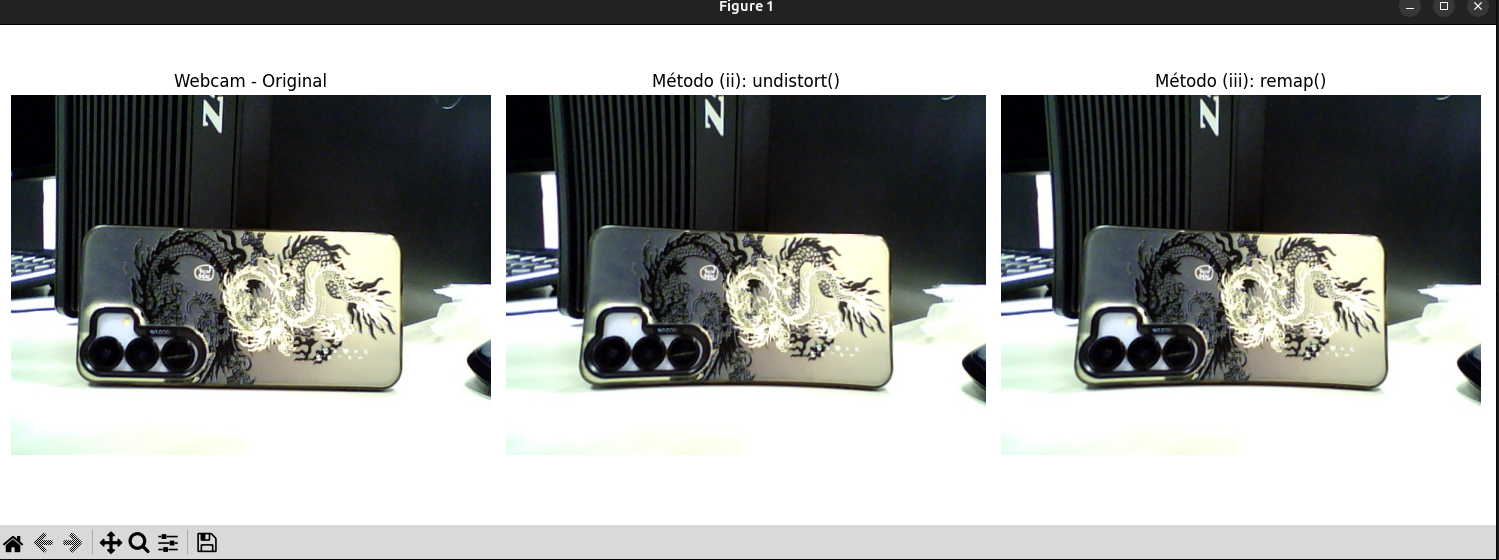

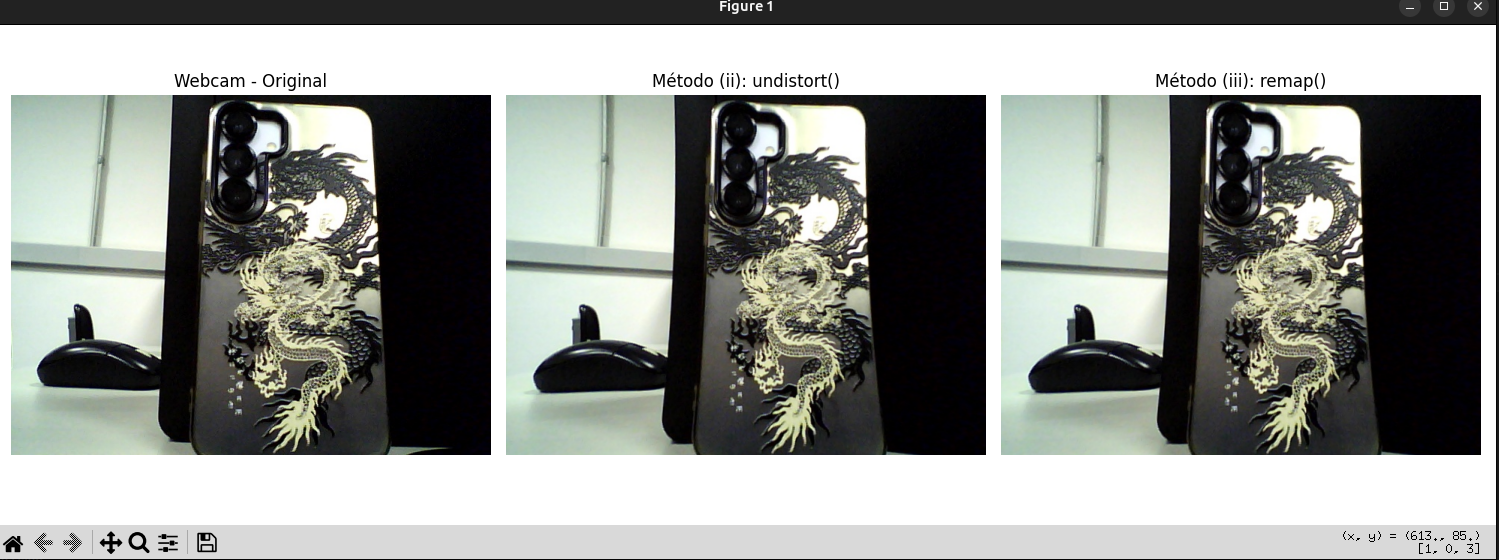

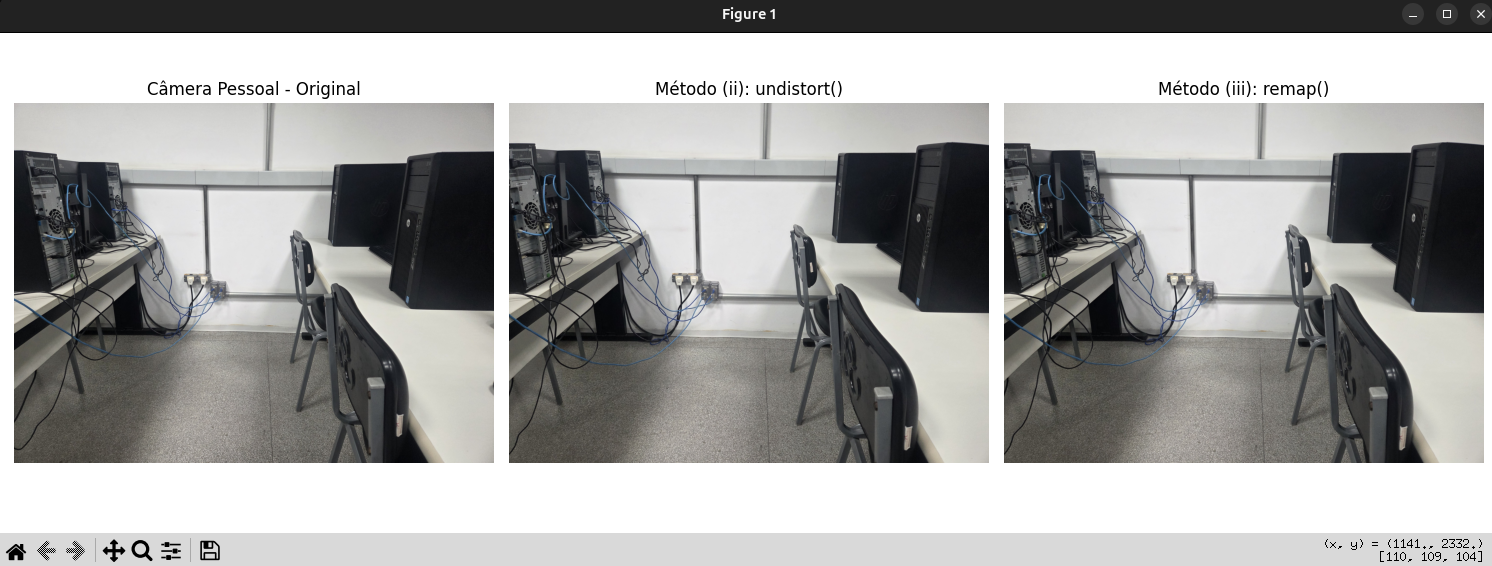

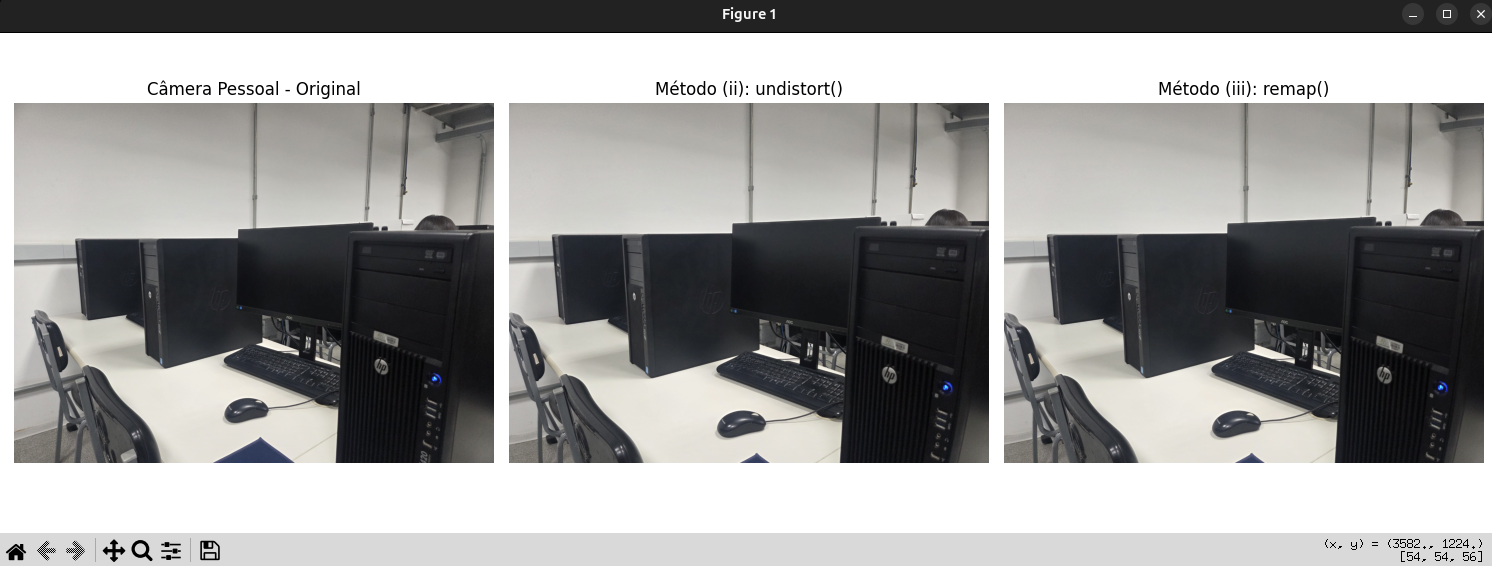

### (D) Correção de Distorção de Imagens: Comparação e Análise

Nesta etapa, utilizamos as matrizes de câmera ($K$) e os vetores de distorção ($dist$) obtidos nas calibrações anteriores para corrigir imagens do mundo real. Foram aplicados dois métodos oferecidos pelo OpenCV: `cv2.undistort()` e remapeamento com `cv2.remap()`.

#### 1. Análise das Imagens da Webcam (Objeto: Capinha de Celular)
* **Imagem Original:** Ao observar a imagem original capturada pela webcam, nota-se uma leve **distorção radial em barril** (barrel distortion). Isso é comum em lentes de webcams (lentes de distâncias focais menores), onde as linhas retas nas bordas da imagem tendem a se curvar para fora a partir do centro.
* **Imagens Corrigidas:** Após a aplicação da correção, o efeito de abaulamento foi matematicamente desfeito. As proporções do objeto tornaram-se mais fiéis à realidade. Além disso, nota-se que a imagem sofreu um leve recorte (crop) nas bordas. Isso ocorreu devido ao uso da função `cv2.getOptimalNewCameraMatrix()` com parâmetro `alpha=0`, que corta as bordas vazias (pretas) geradas ao "esticar" a imagem para endireitá-la.

#### 2. Análise das Imagens da Câmera Pessoal (Cenário: Laboratório)
* **Imagem Original:** Diferente da webcam, a foto do celular praticamente não apresenta distorção radial perceptível a olho nu nas linhas das mesas, paredes ou monitores. Conforme visto no item (C), smartphones modernos possuem conjuntos ópticos sofisticados e, muitas vezes, processamento interno de software que corrige imperfeições antes mesmo de salvar o arquivo `.jpg`.
* **Imagens Corrigidas:** Como os coeficientes de distorção encontrados na calibração do celular eram diferentes da webcam (com $k_1$ positivo, indicando uma levíssima distorção almofada ou tentativa de compensação algorítmica), a transformação aplicada pelo OpenCV foi sutil. As imagens corrigidas ficaram visualmente quase idênticas à original, apresentando apenas um sutil reposicionamento/corte de re-enquadramento causado pelo recálculo da matriz ótima.

#### 3. Comparação dos Métodos: `undistort()` vs `remap()`
Os resultados visuais gerados pelo Método (ii) e pelo Método (iii) foram **absolutamente idênticos** em ambos os casos. Isso valida que os dois processos realizam a mesma transformação matemática nos pixels da imagem.
* A diferença entre eles é puramente computacional: enquanto o `undistort()` faz o cálculo e a correção de uma só vez, o `remap()` utiliza mapas de coordenadas pré-calculados (`mapx`, `mapy`). Em um cenário de processamento de vídeo em tempo real, o uso do `remap()` seria muito mais eficiente, pois os mapas seriam calculados apenas uma vez e aplicados a todos os frames sequenciais.

## <u>Análise e Discussão dos Estudos</u>


A execução prática deste projeto permitiu observar de forma clara como os modelos teóricos de visão computacional se traduzem no comportamento real de diferentes hardwares de captura de imagem. A partir dos dados extraídos e das correções visuais aplicadas, levantamos as seguintes discussões centrais:

#### 1. O Impacto das Especificações de Hardware na Matriz Intrínseca ($K$)
A comparação direta entre a matriz intrínseca da webcam e a do smartphone evidenciou o abismo tecnológico entre os dois sensores.
* **Resolução e Escala:** O centro óptico ($c_x, c_y$) e a distância focal ($f_x, f_y$) da câmera pessoal apresentaram valores na ordem de milhares de pixels (ex: $f_x \approx 2731$), enquanto a webcam apresentou valores na casa das centenas (ex: $f_x \approx 683$). Isso comprova matematicamente que a câmera do celular possui uma densidade de pixels muito superior, cobrindo um plano de imagem vastamente maior.
* **Proporção dos Pixels:** Em ambos os dispositivos, a razão de aspecto ($\frac{f_y}{f_x}$) foi extremamente próxima de $1$. Isso confirma que a premissa de pixels perfeitamente quadrados, assumida na maioria dos algoritmos de visão computacional modernos, é válida para os hardwares atuais.

#### 2. Perfis de Aberração Óptica e Processamento Embutido
A análise do vetor de distorção ($dist$) revelou comportamentos distintos quanto à refração da luz nas extremidades das lentes:
* A **webcam** demonstrou a clássica **distorção em barril** (coeficiente $k_1$ negativo, $-0.062$), típica de lentes esféricas simples e grandes angulares não corrigidas, resultando naquele efeito visual "estufado".
* O **smartphone**, por sua vez, apresentou um $k_1$ positivo ($0.1417$). Lentes de dispositivos móveis topo de linha são compostas por múltiplos elementos ópticos (lentes asféricas) e contam com Processadores de Sinal de Imagem (ISPs) extremamente agressivos. É altamente provável que a imagem do celular já sofra uma correção de distorção de fábrica antes mesmo de o arquivo ser entregue ao usuário, resultando em um perfil de distorção residual mínimo e atípico para o algoritmo de calibração padrão.

#### 3. Parâmetros Extrínsecos e a Variabilidade Espacial
Os vetores de rotação ($R$) e translação ($t$) confirmaram a dinamicidade do modelo. Como esperado, a cada nova imagem (frame) submetida ao algoritmo, um novo conjunto $R$ e $t$ foi gerado. Isso demonstra a capacidade do algoritmo de mapear com precisão o posicionamento relativo 3D da câmera em relação ao tabuleiro de xadrez em cada instante de tempo, validando a eficácia da detecção dos cantos da grade espacial.

#### 4. Validação da Correção Computacional
A aplicação das funções `cv2.undistort()` e `cv2.remap()` comprovou a viabilidade de retificar imagens com base na assinatura matemática da lente.
* A correção da webcam produziu resultados satisfatórios, endireitando geometrias curvadas nas extremidades da foto.
* Constatou-se também que os parâmetros intrínsecos são **exclusivos da lente calibrada** (são como uma "impressão digital"). Tentar utilizar a matriz $K$ e o vetor $dist$ da webcam para corrigir uma foto tirada pelo celular geraria uma transformação matemática incorreta, induzindo distorções artificiais na imagem.
* Por fim, verificou-se que `undistort` e `remap` entregam matrizes de pixels resultantes idênticas, mas o mapeamento pré-calculado do `remap` se mostrou a abordagem ideal para sistemas de tempo real (como robótica e rastreamento de vídeo), devido à sua maior eficiência computacional.

## <u>Conclusão</u>

Este trabalho demonstrou na prática a importância e a eficácia do processo de calibração de câmeras na área de Visão Computacional. Através da implementação do método de Zhang com o auxílio da biblioteca OpenCV, foi possível modelar matematicamente o comportamento óptico de dois dispositivos distintos, extraindo com sucesso suas matrizes intrínsecas, parâmetros extrínsecos e coeficientes de distorção.

A análise comparativa evidenciou de forma clara como as características físicas do hardware afetam a captura geométrica do mundo. Enquanto a webcam apresentou a clássica distorção em barril e parâmetros condizentes com um sensor de menor resolução, a câmera do smartphone revelou uma arquitetura óptica muito mais avançada, com altíssima distância focal e um perfil de distorção mitigado por processamento digital embutido. Tais resultados reforçam a premissa de que os parâmetros de calibração funcionam como uma "impressão digital" da lente, sendo únicos e intransferíveis entre dispositivos.

Na etapa de retificação de imagens, comprovou-se a utilidade prática desses modelos teóricos. As funções de correção computacional aplicadas (`undistort` e `remap`) foram plenamente capazes de reverter as aberrações da lente da webcam, restaurando a linearidade e as proporções reais dos objetos em cena. Constatou-se também que, embora ambos os métodos entreguem matrizes de pixels resultantes idênticas, o remapeamento se destaca como a solução computacional mais eficiente para aplicações contínuas, como processamento de vídeo em tempo real.

Por fim, conclui-se que a calibração de câmeras transcende um mero ajuste estético em imagens. Ela é um pré-requisito técnico absoluto e indispensável para qualquer sistema que pretenda extrair dados métricos precisos a partir de pixels. Sem essa correção inicial, aplicações avançadas como reconstrução 3D, fotogrametria, navegação autônoma de robôs e realidade aumentada não teriam a confiabilidade geométrica necessária para operar no mundo real.

## <u>Referências</u>

### Referências Bibliográficas

Em consonância com a norma com a portaria 2664/2026 da Cnpq, declaramos que durante o desenvolvimento deste trabalho, foram utilizadas ferramentas de inteligência artificial generativa de forma auxiliar. O assistente ChatGPT GPT-4o e Gemini 2.5 Flash foi empregado para revisão ortográfica e gramatical e formatação de referências bibliográficas. Todo o conteúdo intelectual, a análise crítica, a interpretação dos dados e as conclusões são de autoria exclusiva dos discentes. As saídas das ferramentas de IA foram integralmente revisadas e reescritas pelo autor antes da incorporação ao texto.


* ZHANG, Zhengyou. A flexible new technique for camera calibration. *IEEE Transactions on Pattern Analysis and Machine Intelligence*, v. 22, n. 11, p. 1330-1334, 2000. Disponível em: <https://ieeexplore.ieee.org/document/888718>.

* SZELISKI, Richard. *Computer Vision: Algorithms and Applications*. 2. ed. Springer, 2022..
* HARTLEY, Richard; ZISSERMAN, Andrew. *Multiple View Geometry in Computer Vision*. 2. ed. Cambridge University Press, 2004.

* OPENCV. *Camera Calibration and 3D Reconstruction*. Open Source Computer Vision Library Documentation, [s.d.]. Disponível em: <https://docs.opencv.org/4.x/d9/d0c/group__calib3d.html>. Acesso em: 06 jul. 2026.
* OPENCV. *Camera Calibration Tutorial*. Open Source Computer Vision Library Documentation, [s.d.]. Disponível em: <https://docs.opencv.org/4.x/dc/dbb/tutorial_py_calibration.html>. Acesso em: 06 jul. 2026.